# Simple model with Flow Matching

Attempting to do the same thing as in `simple_model.ipynb`, but using Flow Matching instead of MCMC sampling. 

In [ ]:
from typing import Optional, List, Type, Tuple, Dict

import sys
sys.path.append('..')

from src.helpers import plot_trace
from src.simulator import BurstSimulator, Model
from src.flow_matching.probability_path import Sampleable, LinearConditionalProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer, MLPVectorField
from src.flow_matching.integration import LearnedVectorFieldODE, EulerODESolver

import numpy as np
import matplotlib.cm as cm
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [17]:
# Several plotting utility functions
def hist2d_samples(samples, ax: Optional[Axes] = None, bins: int = 200, scale: float = 5.0, percentile: int = 99, **kwargs):
    H, xedges, yedges = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, range=[[-scale, scale], [-scale, scale]])

    # Determine color normalization based on the 99th percentile
    cmax = np.percentile(H, percentile)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

    # Plot using imshow for more control
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    ax.imshow(H.T, extent=extent, origin='lower', norm=norm, **kwargs)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

# Example from MIT Lab two

In [18]:
class Gaussian(torch.nn.Module, Sampleable):
    """
    Multivariate Gaussian distribution
    """
    def __init__(self, mean: torch.Tensor, cov: torch.Tensor):
        """
        mean: shape (dim,)
        cov: shape (dim,dim)
        """
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("cov", cov)

    @property
    def dim(self) -> int:
        return self.mean.shape[0]

    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples) -> torch.Tensor:
        return self.distribution.sample((num_samples,))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)

    @classmethod
    def isotropic(cls, dim: int, std: float) -> "Gaussian":
        mean = torch.zeros(dim)
        cov = torch.eye(dim) * std ** 2
        return cls(mean, cov)
    
class CheckerboardSampleable(Sampleable):
    """
    Checkboard-esque distribution
    """
    def __init__(self, device: torch.device, grid_size: int = 3, scale=5.0):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0,2).to(device)
        while samples.shape[0] < num_samples:
            # Sample num_samples
            new_samples = (torch.rand(num_samples,2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:,0] + self.scale) / grid_length) % 2 == 0 # (bs,)
            y_mask = torch.floor((new_samples[:,1] + self.scale) / grid_length) % 2 == 0 # (bs,)
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)
        return samples[:num_samples]

In [ ]:
# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Gaussian.isotropic(dim=2, std=1.0),
    p_data = CheckerboardSampleable(device, grid_size=4)
).to(device)

# Construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000)


Training model with size: 0.049 MiB


Epoch 1, loss: 18.768: : 0it [00:00, ?it/s]

Epoch 6, loss: 18.594: : 4it [00:00, 33.22it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([-2.3055, -2.2496])


Epoch 999, loss: 8.757: : 1000it [00:13, 74.59it/s]


100%|██████████| 99/99 [00:04<00:00, 21.46it/s]


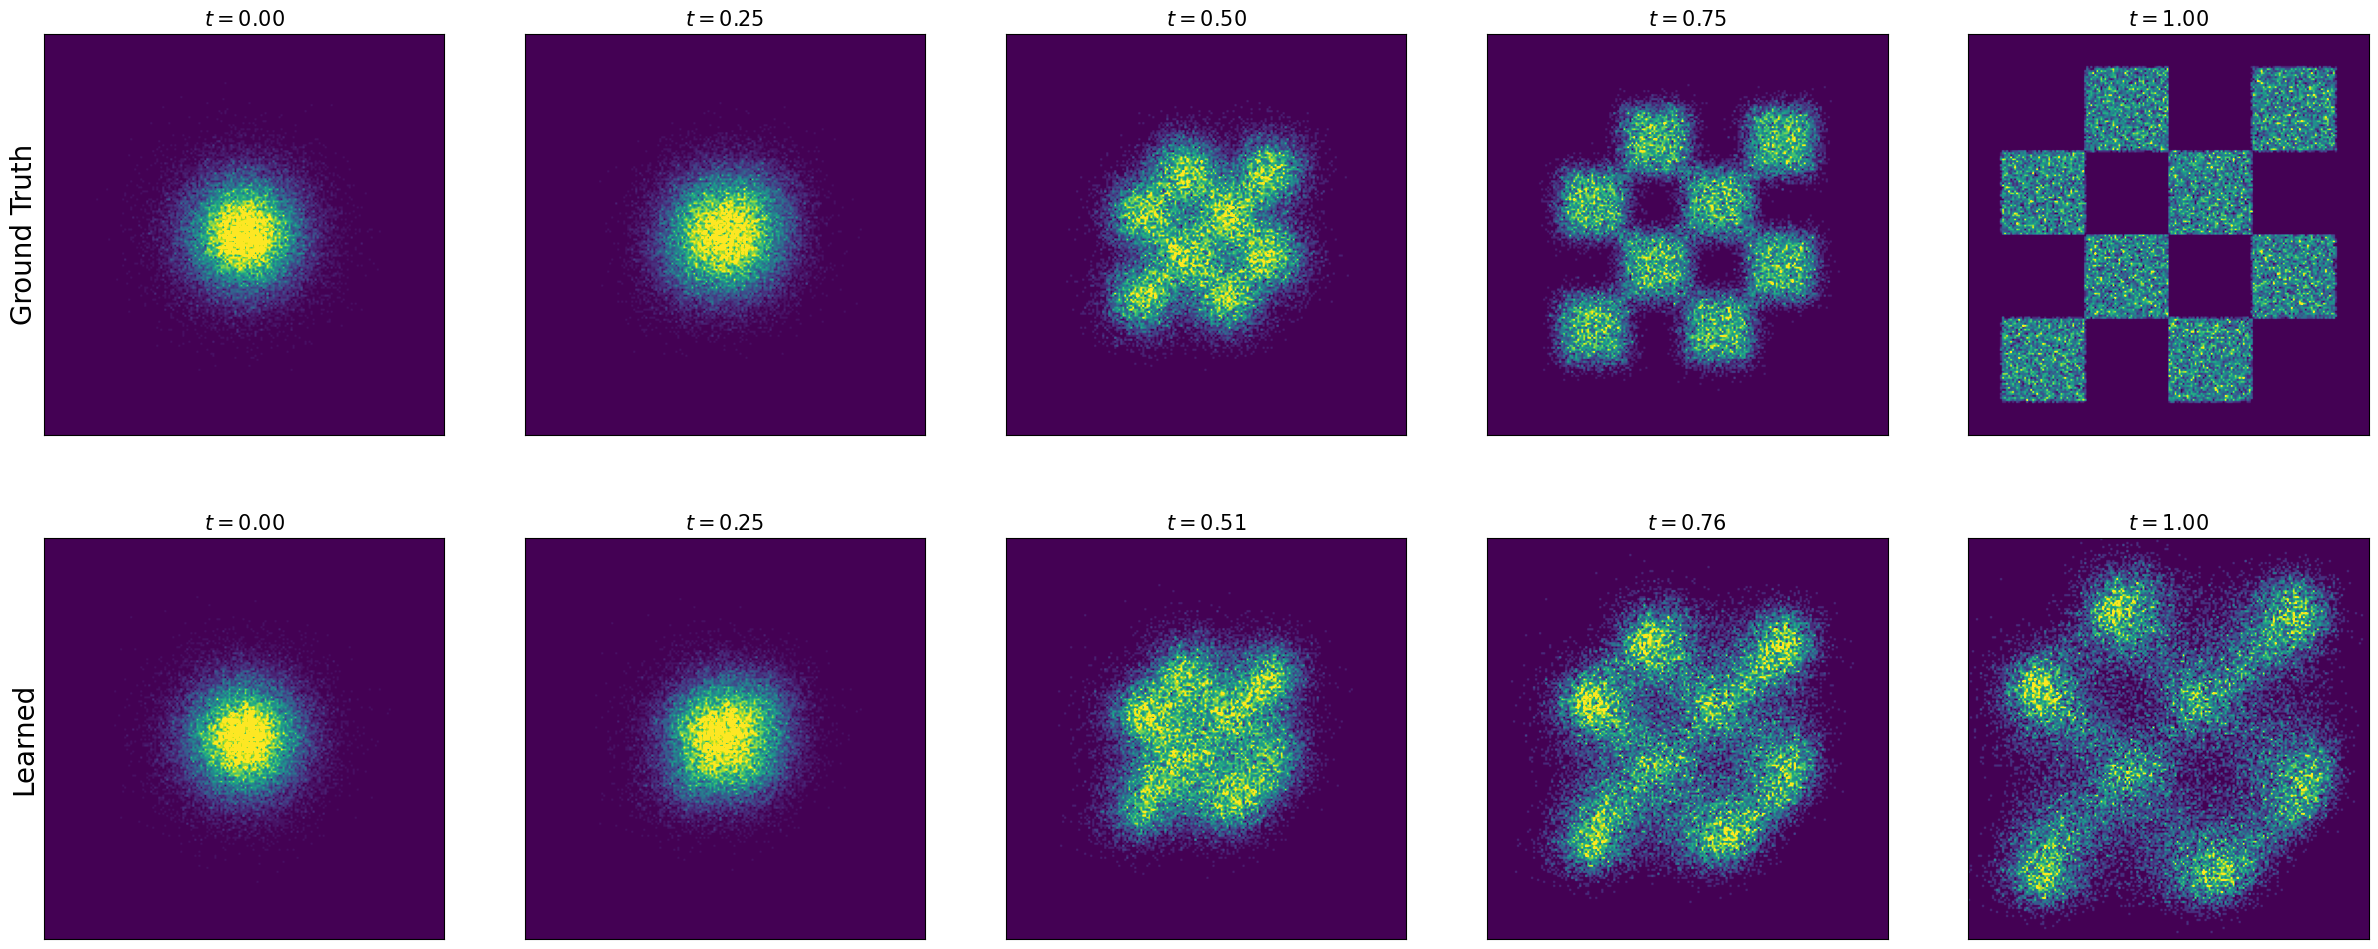

In [20]:
##########################
# Play around With These #
##########################
num_samples = 50000
num_marginals = 5

##############
# Setup Plots #
##############

fig, axes = plt.subplots(2, num_marginals, figsize=(6 * num_marginals, 6 * 2))
axes = axes.reshape(2, num_marginals)
scale = 6.0

###########################
# Graph Ground-Truth Marginals #
###########################
ts = torch.linspace(0.0, 1.0, num_marginals).to(device)
for idx, t in enumerate(ts):
    tt = t.view(1,1).expand(num_samples,1)
    xts = path.sample_marginal_path(tt)
    hist2d_samples(samples=xts.cpu(), ax=axes[0, idx], bins=200, scale=scale, percentile=99, alpha=1.0)
    axes[0, idx].set_xlim(-scale, scale)
    axes[0, idx].set_ylim(-scale, scale)
    axes[0, idx].set_xticks([])
    axes[0, idx].set_yticks([])
    axes[0, idx].set_title(f'$t={t.item():.2f}$', fontsize=15)
axes[0, 0].set_ylabel("Ground Truth", fontsize=20)

###############################################
# Graph Marginals of Learned Vector Field #
###############################################
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))
xts = xts[:,record_every_idxs,:]
for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    hist2d_samples(samples=xx.cpu(), ax=axes[1, idx], bins=200, scale=scale, percentile=99, alpha=1.0)
    axes[1, idx].set_xlim(-scale, scale)
    axes[1, idx].set_ylim(-scale, scale)
    axes[1, idx].set_xticks([])
    axes[1, idx].set_yticks([])
    tt = ts[record_every_idxs[idx]]
    axes[1, idx].set_title(f'$t={tt.item():.2f}$', fontsize=15)
axes[1, 0].set_ylabel("Learned", fontsize=20)

plt.show()

# Example CFM for SBI

In [27]:
# Need to change 
# Samplelable prior for t0_1 and t0_2
class Prior(Sampleable):
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_samples, _ = torch.sort(torch.rand((num_samples, self.dim)), dim=1)
        return t0_samples.to(device)

# Samplelable posterior 
class Posterior(Sampleable):

    """
    This is now for a given datapoint, so just returns true_t0_1, true_t0_2
    """
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_1 = 0.1 * torch.ones((num_samples, 1))
        t0_2 = 0.6 * torch.ones((num_samples, 1))
        return torch.cat((t0_1, t0_2), dim=1)

# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Prior(),# should be Sampleable prior 
    p_data = Posterior() # this should be posterior sample (+ labels, i.e. simulated data, later on)
).to(device)

# Construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000)

Training model with size: 0.049 MiB


Epoch 4, loss: 0.173: : 0it [00:00, ?it/s]

Epoch 10, loss: 0.124: : 6it [00:00, 59.29it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([0.1000, 0.6000])


Epoch 999, loss: 0.003: : 1000it [00:15, 66.52it/s]


100%|██████████| 99/99 [00:00<00:00, 107.85it/s]


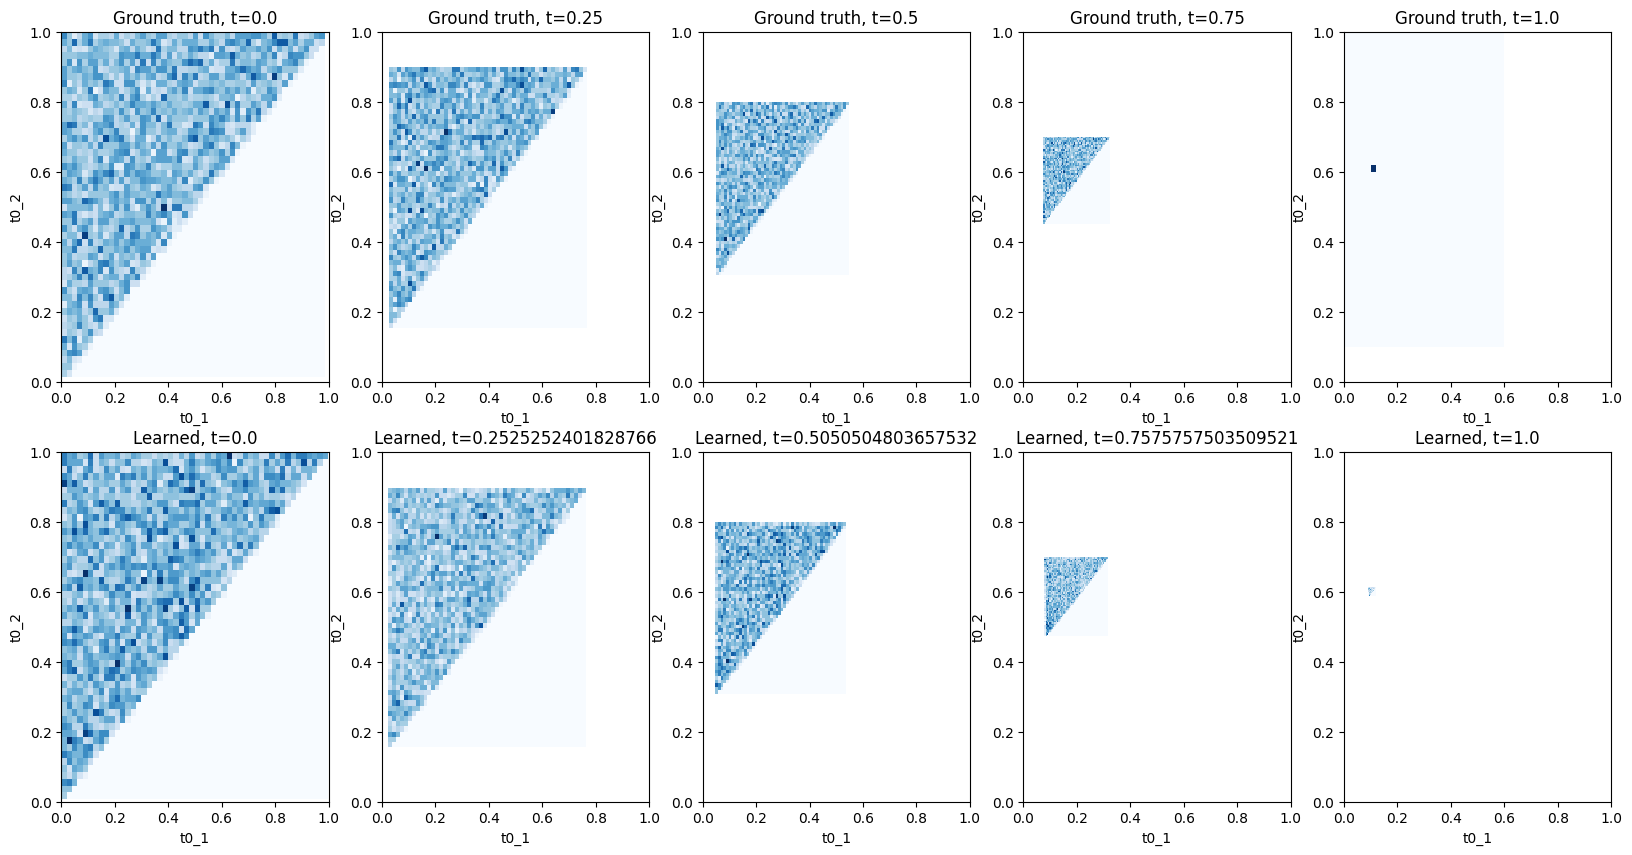

In [56]:
##########################
# Play around With These #
##########################
num_samples = 10000
num_marginals = 5

plt.figure(figsize=(20, 10))

###########################
# Graph Ground-Truth Marginals #
###########################
ts = torch.linspace(0.0, 1.0, num_marginals).to(device)
for idx, t in enumerate(ts):
    tt = t.view(1,1).expand(num_samples,1)
    xts = path.sample_marginal_path(tt)
    t = tt.cpu()[0][0]

    plt.subplot(2, num_marginals, idx + 1)

    
    plt.hist2d(x=xts[:, 0], y=xts[:, 1], bins=50, cmap='Blues')

    plt.title(f"Ground truth, t={t}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0,1)

###############################################
# Graph Marginals of Learned Vector Field #
###############################################
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))
xts = xts[:,record_every_idxs,:]

subplot_idx = idx + 1 # for plotting 

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(2, num_marginals, subplot_idx + idx + 1)
    
    plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    
    plt.title(f"Learned, t={t}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# Adding guiding with simulated data for fixed parameters